# 08 · Three-Model Comparison & War Shock Analysis

**Project:** War Shocks & Global Financial Risk Spillover  
**Models:** VAR (baseline) · LSTM · GRU  
**Evaluation:** MSE / MAE / RMSE / MAPE / DirAcc, h = 1 / 5 / 10 / 22  
**Ref:** Kumar et al. (2024, arXiv:2410.16858); Diebold & Yilmaz (2009, 2012)  

**Outputs:**  
- `outputs/tables/table_average_summary.xlsx`  
- `outputs/tables/table_master_comparison.xlsx`  
- `outputs/tables/table_regime_metrics.xlsx`  
- `outputs/tables/table_db_ratio.xlsx`  
- `outputs/figures/fig14_mse_comparison.png`  
- `outputs/figures/fig15_mape_degradation.png`  
- `outputs/figures/fig16_diracc.png`  
- `outputs/figures/fig17_db_ratio.png`  
- `outputs/figures/fig18_mse_heatmap.png`

## 1 · Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from src.data_loader  import DATA_PROC_DIR
from src.var_models   import EQUITY_COLS, HORIZONS
from src.evaluation   import (
    compute_regime_metrics,
    build_average_summary, build_master_table,
    build_regime_table, build_ratio_table,
    plot_mse_bars, plot_mape_lines,
    plot_diracc_lines, plot_db_ratio, plot_mse_heatmap,
)

TABLE_DIR = os.path.join("..", "outputs", "tables")
FIG_DIR   = os.path.join("..", "outputs", "figures")
os.makedirs(TABLE_DIR, exist_ok=True)
os.makedirs(FIG_DIR,   exist_ok=True)

print("HORIZONS   :", HORIZONS)
print("EQUITY_COLS:", EQUITY_COLS)

HORIZONS   : [1, 5, 10, 22]
EQUITY_COLS: ['SP500_vol', 'DAX_vol', 'CAC40_vol', 'FTSE100_vol', 'Nikkei_vol', 'KOSPI_vol', 'HangSeng_vol', 'SSE_vol']


## 2 · Load All Model Metrics

In [2]:
def load_metrics(model_prefix):
    frames = []
    for h in HORIZONS:
        path = os.path.join(TABLE_DIR, f"table_{model_prefix}_metrics_h{h}.xlsx")
        df   = pd.read_excel(path)
        df["Horizon"] = h
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

metrics_var  = load_metrics("var");  metrics_var["Model"]  = "VAR"
metrics_lstm = load_metrics("lstm"); metrics_lstm["Model"] = "LSTM"
metrics_gru  = load_metrics("gru");  metrics_gru["Model"]  = "GRU"

all_metrics = pd.concat([metrics_var, metrics_lstm, metrics_gru],
                         ignore_index=True)

print(f"VAR  : {metrics_var.shape}")
print(f"LSTM : {metrics_lstm.shape}")
print(f"GRU  : {metrics_gru.shape}")
print(f"All  : {all_metrics.shape}")
print("Labels:", all_metrics["Label"].unique())

VAR  : (72, 10)
LSTM : (72, 10)
GRU  : (72, 10)
All  : (216, 10)
Labels: ['VAR_Val' 'VAR_Test' 'LSTM_Val' 'LSTM_Test' 'GRU_Val' 'GRU_Test']


## 3 · Table — Average Summary (Val + Test, all horizons)
AVERAGE across 8 markets.

In [3]:
summary_df = build_average_summary(all_metrics, horizons=HORIZONS)
print(summary_df.to_string(index=False))

Period Horizon  VAR_MSE  VAR_MAPE  VAR_DirAcc  LSTM_MSE  LSTM_MAPE  LSTM_DirAcc  GRU_MSE  GRU_MAPE  GRU_DirAcc
   Val     h=1 0.000615      7.75       0.499  0.000378       6.59        0.540 0.000301      5.67       0.552
   Val     h=5 0.002240     17.42       0.459  0.001956      17.96        0.481 0.001854     16.40       0.495
   Val    h=10 0.005411     26.39       0.456  0.004202      27.18        0.488 0.004226     24.82       0.480
   Val    h=22 0.013895     39.71       0.482  0.012389      36.23        0.491 0.013349     36.41       0.495
  Test     h=1 0.000589      7.32       0.500  0.000291       6.65        0.529 0.000271      5.82       0.523
  Test     h=5 0.002103     16.12       0.492  0.001986      18.95        0.511 0.001960     17.35       0.511
  Test    h=10 0.004064     24.55       0.480  0.003714      26.28        0.508 0.003553     24.29       0.506
  Test    h=22 0.007564     37.64       0.507  0.006553      36.79        0.522 0.006674     38.20       0.512


## 4 · Table — Master Comparison (per market × model × horizon)
Cell = MSE (MAPE%). Separate sheets for Val and Test.

In [4]:
table_val  = build_master_table(all_metrics, "Val",  EQUITY_COLS, horizons=HORIZONS)
table_test = build_master_table(all_metrics, "Test", EQUITY_COLS, horizons=HORIZONS)
print("=== Test Period ===")
print(table_test.to_string(index=False))

=== Test Period ===
   Market          VAR_h1           VAR_h5          VAR_h10          VAR_h22          LSTM_h1          LSTM_h5         LSTM_h10         LSTM_h22          GRU_h1           GRU_h5          GRU_h10          GRU_h22
  S&P 500 0.000340 (6.7%) 0.001328 (14.9%) 0.002953 (23.6%) 0.006549 (36.6%)  0.000212 (5.7%) 0.001529 (15.0%) 0.003610 (21.3%) 0.005887 (25.6%) 0.000172 (4.9%) 0.002579 (21.7%) 0.003425 (20.7%) 0.004986 (25.7%)
      DAX 0.000466 (7.5%) 0.001591 (16.2%) 0.003228 (24.8%) 0.006413 (39.2%)  0.000199 (7.2%) 0.001040 (15.8%) 0.001806 (21.9%) 0.003979 (40.8%) 0.000182 (5.9%) 0.000850 (14.3%) 0.001669 (19.8%) 0.003545 (37.0%)
   CAC 40 0.000394 (7.6%) 0.001419 (16.8%) 0.002940 (24.9%) 0.005947 (38.9%)  0.000139 (6.1%) 0.001073 (18.3%) 0.001691 (23.6%) 0.004059 (42.2%) 0.000136 (5.4%) 0.000822 (15.5%) 0.001892 (25.0%) 0.002539 (28.9%)
 FTSE 100 0.000278 (7.8%) 0.001139 (18.0%) 0.002502 (29.7%) 0.004968 (49.9%) 0.000172 (10.2%) 0.001319 (28.8%) 0.001556 (27.6%) 0.00

## 5 · Regime-Conditional Metrics (Test, h=1)
Regimes: **B** War-Only | **C** Crisis-Only | **D** War+Crisis

In [5]:
war_df = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                        index_col=0, parse_dates=True)

def load_test_fc(prefix):
    act = pd.read_excel(os.path.join(TABLE_DIR, f"{prefix}_actual_test.xlsx"),
                         index_col=0, parse_dates=True)
    fc  = pd.read_excel(os.path.join(TABLE_DIR, f"{prefix}_forecast_test.xlsx"),
                         index_col=0, parse_dates=True)
    return act, fc

act_var,  fc_var  = load_test_fc("var")
act_lstm, fc_lstm = load_test_fc("lstm")
act_gru,  fc_gru  = load_test_fc("gru")

regime_var  = compute_regime_metrics(act_var,  fc_var,  war_df)
regime_lstm = compute_regime_metrics(act_lstm, fc_lstm, war_df)
regime_gru  = compute_regime_metrics(act_gru,  fc_gru,  war_df)

regime_dict = {"VAR": regime_var, "LSTM": regime_lstm, "GRU": regime_gru}

regime_df = build_regime_table(regime_dict)
print(regime_df.to_string(index=False))

Model         Regime   n      MSE     RMSE  MAPE
  VAR    B: War-Only  50 0.000263 0.014185  6.97
  VAR C: Crisis-Only   0      NaN      NaN   NaN
  VAR  D: War+Crisis   0      NaN      NaN   NaN
  VAR      Full Test 810 0.000589 0.023554  7.32
 LSTM    B: War-Only  50 0.000215 0.013171  6.95
 LSTM C: Crisis-Only   0      NaN      NaN   NaN
 LSTM  D: War+Crisis   0      NaN      NaN   NaN
 LSTM      Full Test 766 0.000291 0.016615  6.65
  GRU    B: War-Only  50 0.000218 0.012560  5.87
  GRU C: Crisis-Only   0      NaN      NaN   NaN
  GRU  D: War+Crisis   0      NaN      NaN   NaN
  GRU      Full Test 750 0.000271 0.015937  5.82


## 6 · B/Full Ratio — War-Period Forecast Error
**B/Full = RMSE(B: War-Only) / RMSE(Full Test)**  
Ratio < 1: war-period error is **below** test average (market has priced in war risk, volatility not anomalous).  
Ratio > 1: war-period error is amplified above average.  

> Note: D: War+Crisis has 0 obs in test period (2022–2025) — no systemic financial crisis coincides with Israel-Hamas war. B vs Full Test is therefore the operative war-shock comparison.

In [6]:
ratio_df = build_ratio_table(regime_dict)
print(ratio_df.to_string(index=False))

Model  B_n   B_RMSE  Full_n  Full_RMSE  B_Full_ratio
  VAR   50 0.014185     810   0.023554         0.602
 LSTM   50 0.013171     766   0.016615         0.793
  GRU   50 0.012560     750   0.015937         0.788


## 7 · Fig 14 · MSE by Horizon (VAR vs LSTM vs GRU)

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig14_mse_comparison.png


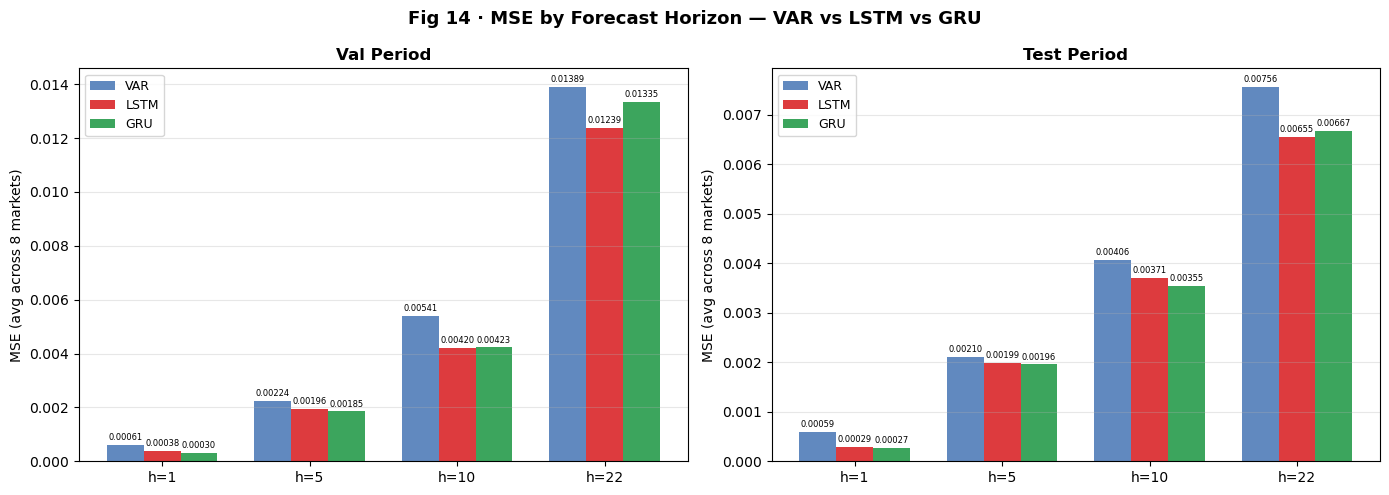

In [7]:
plot_mse_bars(all_metrics, HORIZONS)

## 8 · Fig 15 · MAPE Degradation with Horizon

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig15_mape_degradation.png


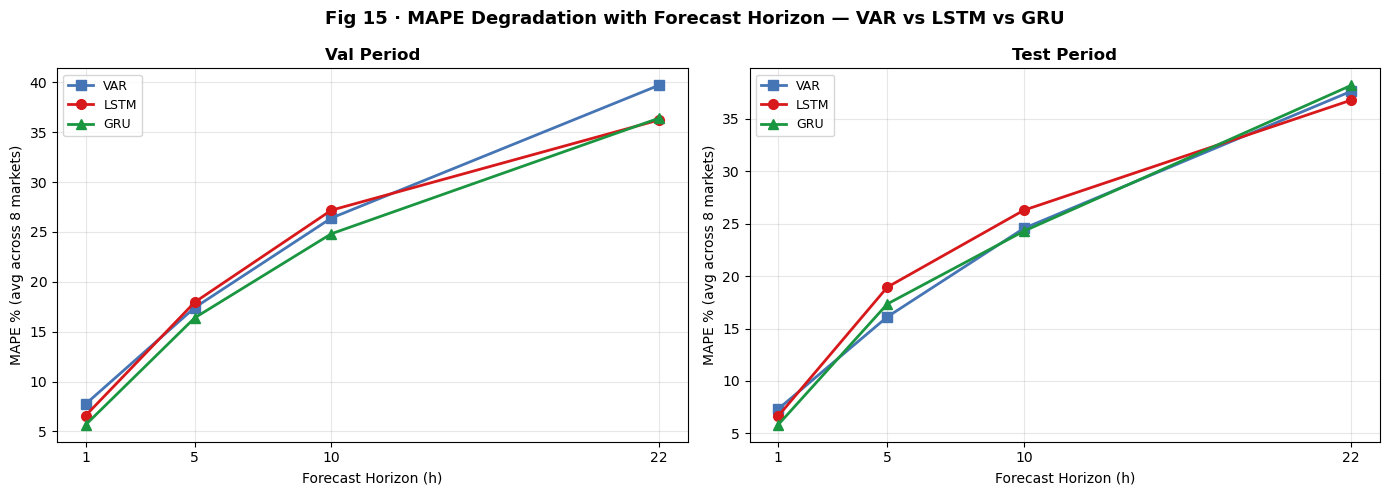

In [8]:
plot_mape_lines(all_metrics, HORIZONS)

## 9 · Fig 16 · Direction Accuracy vs Random Walk

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig16_diracc.png


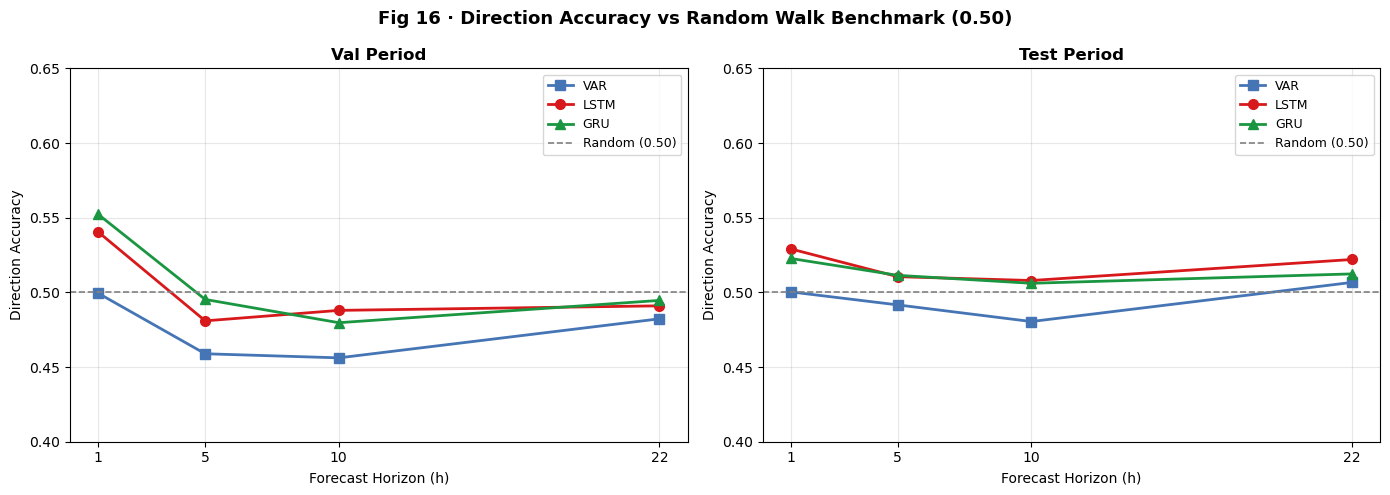

In [9]:
plot_diracc_lines(all_metrics, HORIZONS)

## 10 · Fig 17 · D/B Amplification Ratio

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig17_war_rmse.png


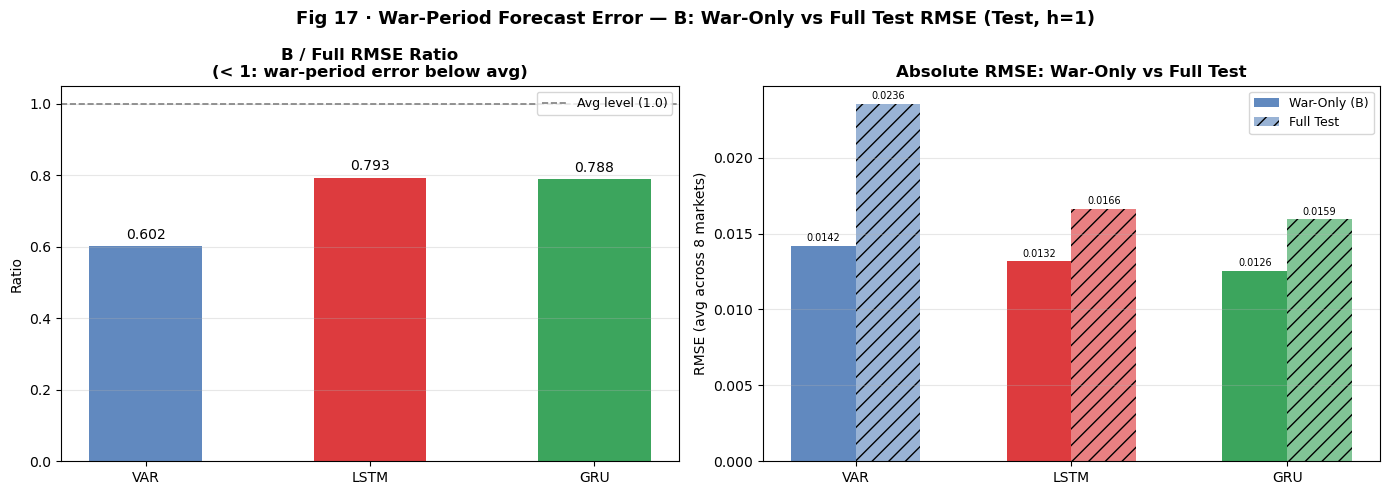

In [10]:
plot_db_ratio(regime_dict)

## 11 · Fig 18 · Per-Market MSE Heatmap (Test)

Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig18_mse_heatmap.png


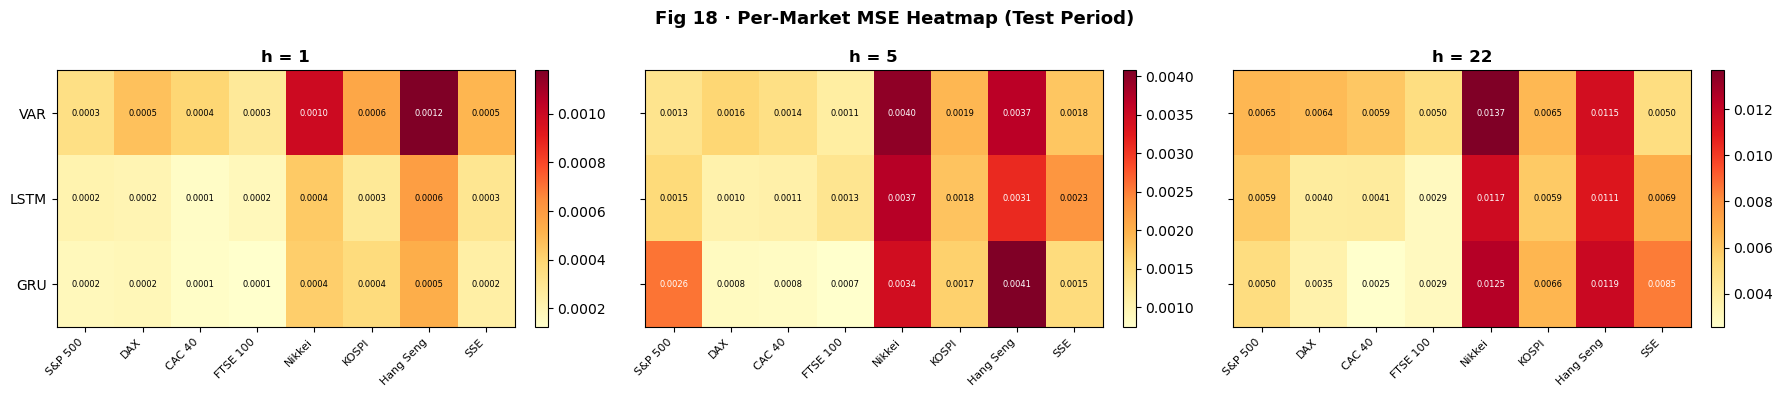

In [11]:
plot_mse_heatmap(all_metrics, EQUITY_COLS)

## 12 · Save All Tables

In [12]:
# Average summary
summary_df.to_excel(os.path.join(TABLE_DIR, "table_average_summary.xlsx"),
                     index=False)
print("Saved → table_average_summary.xlsx")

# Master comparison (val + test)
with pd.ExcelWriter(os.path.join(TABLE_DIR, "table_master_comparison.xlsx")) as writer:
    table_val.to_excel(writer,  sheet_name="Val_MSE_MAPE",  index=False)
    table_test.to_excel(writer, sheet_name="Test_MSE_MAPE", index=False)
print("Saved → table_master_comparison.xlsx")

# Regime metrics
regime_df.to_excel(os.path.join(TABLE_DIR, "table_regime_metrics.xlsx"),
                    index=False)
print("Saved → table_regime_metrics.xlsx")

# D/B ratio
ratio_df.to_excel(os.path.join(TABLE_DIR, "table_db_ratio.xlsx"),
                   index=False)
print("Saved → table_db_ratio.xlsx")

Saved → table_average_summary.xlsx
Saved → table_master_comparison.xlsx
Saved → table_regime_metrics.xlsx
Saved → table_db_ratio.xlsx
